<a href="https://colab.research.google.com/github/PatriciaKiarie04/sentiment-analysis-nlp/blob/main/sentiment_analysis_nlp_csv.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd

df = pd.read_csv('/Reviews.csv', nrows=10000)
print(df.shape)
print(df.columns.tolist())
df.head()

(10000, 10)
['Id', 'ProductId', 'UserId', 'ProfileName', 'HelpfulnessNumerator', 'HelpfulnessDenominator', 'Score', 'Time', 'Summary', 'Text']


,Id,ProductId,UserId,ProfileName,HelpfulnessNumerator,HelpfulnessDenominator,Score,Time,Summary,Text
0,1,B001E4KFG0,A3SGXH7AUHU8GW,delmartian,1,1,5,1303862400,Good Quality Dog Food,I have bought several of the Vitality canned d...
1,2,B00813GRG4,A1D87F6ZCVE5NK,dll pa,0,0,1,1346976000,Not as Advertised,Product arrived labeled as Jumbo Salted Peanut...
2,3,B000LQOCH0,ABXLMWJIXXAIN,"Natalia Corres ""Natalia Corres""",1,1,4,1219017600,"""Delight"" says it all",This is a confection that has been around a fe...
3,4,B000UA0QIQ,A395BORC6FGVXV,Karl,3,3,2,1307923200,Cough Medicine,If you are looking for the secret ingredient i...
4,5,B006K2ZZ7K,A1UQRSCLF8GW1T,"Michael D. Bigham ""M. Wassir""",0,0,5,1350777600,Great taffy,Great taffy at a great price. There was a wid...


opening a new Colab session you need to mount Drive first before accessing files. It only takes a few seconds which is much faster than re-uploading the whole large file.

In [4]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [5]:
import pandas as pd
df = pd.read_csv('/content/drive/MyDrive/Reviews.csv', nrows=10000)
print(df.shape)
df.head()

(10000, 10)


,Id,ProductId,UserId,ProfileName,HelpfulnessNumerator,HelpfulnessDenominator,Score,Time,Summary,Text
0,1,B001E4KFG0,A3SGXH7AUHU8GW,delmartian,1,1,5,1303862400,Good Quality Dog Food,I have bought several of the Vitality canned d...
1,2,B00813GRG4,A1D87F6ZCVE5NK,dll pa,0,0,1,1346976000,Not as Advertised,Product arrived labeled as Jumbo Salted Peanut...
2,3,B000LQOCH0,ABXLMWJIXXAIN,"Natalia Corres ""Natalia Corres""",1,1,4,1219017600,"""Delight"" says it all",This is a confection that has been around a fe...
3,4,B000UA0QIQ,A395BORC6FGVXV,Karl,3,3,2,1307923200,Cough Medicine,If you are looking for the secret ingredient i...
4,5,B006K2ZZ7K,A1UQRSCLF8GW1T,"Michael D. Bigham ""M. Wassir""",0,0,5,1350777600,Great taffy,Great taffy at a great price. There was a wid...


Drop columns that are not needed

In [6]:
# Keep only the columns we need for sentiment analysis
df = df[['Score', 'Summary', 'Text']]
print(df.shape)
df.head()

(10000, 3)


,Score,Summary,Text
0,5,Good Quality Dog Food,I have bought several of the Vitality canned d...
1,1,Not as Advertised,Product arrived labeled as Jumbo Salted Peanut...
2,4,"""Delight"" says it all",This is a confection that has been around a fe...
3,2,Cough Medicine,If you are looking for the secret ingredient i...
4,5,Great taffy,Great taffy at a great price. There was a wid...


Convert Score to Sentiment

In [7]:
# Convert star ratings to sentiment labels
# 4-5 stars = Positive, 1-2 stars = Negative, drop 3 stars (neutral/unclear)
df = df[df['Score'] != 3]

df['Sentiment'] = df['Score'].apply(lambda x: 'Positive' if x >= 4 else 'Negative')

# Check the balance
print(df['Sentiment'].value_counts())

Sentiment
Positive    7616
Negative    1522
Name: count, dtype: int64


Balance the dataset -Takes all 1522 negative reviews
Randomly picks 1522 positive reviews to match
Combines and shuffles them so they're mixed evenly

In [8]:
# Get all negative reviews
negative = df[df['Sentiment'] == 'Negative']

# Sample equal number of positive reviews
positive = df[df['Sentiment'] == 'Positive'].sample(n=1522, random_state=42)

# Combine them into a balanced dataset
df_balanced = pd.concat([positive, negative])

# Shuffle the rows
df_balanced = df_balanced.sample(frac=1, random_state=42).reset_index(drop=True)

# Check the balance
print(df_balanced['Sentiment'].value_counts())
print(f"Total reviews: {df_balanced.shape[0]}")

Sentiment
Positive    1522
Negative    1522
Name: count, dtype: int64
Total reviews: 3044


Clean the review text

In [9]:
import re
import nltk
nltk.download('stopwords')
from nltk.corpus import stopwords

stop_words = set(stopwords.words('english'))

def clean_text(text):
    # Convert to lowercase
    text = text.lower()
    # Remove punctuation and numbers
    text = re.sub(r'[^a-z\s]', '', text)
    # Remove stopwords
    text = ' '.join([word for word in text.split() if word not in stop_words])
    return text

# Apply cleaning to Text column
df_balanced['Clean_Text'] = df_balanced['Text'].apply(clean_text)

# Compare before and after
print("BEFORE:", df_balanced['Text'].iloc[0])
print("\nAFTER:", df_balanced['Clean_Text'].iloc[0])

BEFORE: Can't complain. Taste good and had quick delivery! It was my first time trying this tea out. I usually drink the peppermint one but this gave me energy and sustained me throughout the day.

AFTER: cant complain taste good quick delivery first time trying tea usually drink peppermint one gave energy sustained throughout day


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


Convert cleaned review text into numerical features using TF-IDF
Each review becomes a row of 5000 numbers representing the importance
of each word this is how we translate language into something
a machine learning model can understand and learn from

In [10]:
from sklearn.feature_extraction.text import TfidfVectorizer

# Convert cleaned text into numerical features
tfidf = TfidfVectorizer(max_features=5000)
X = tfidf.fit_transform(df_balanced['Clean_Text'])
y = df_balanced['Sentiment']

print(f"Matrix shape: {X.shape}")

Matrix shape: (3044, 5000)


Train/Test Split

In [11]:
# Split into training and testing sets
# 80% for training, 20% for testing - same approach as project 1
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Training samples: {X_train.shape[0]}")
print(f"Testing samples: {X_test.shape[0]}")

Training samples: 2435
Testing samples: 609


 Building the Model - using logistic regression

In [12]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

# Build and train the model
# This comment goes above the code as a text cell
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

# Evaluate the model
y_pred = model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print(f"Model Accuracy: {accuracy * 100:.2f}%")

Model Accuracy: 83.42%


Deeper evaluation

In [13]:
# Detailed breakdown of model performance by sentiment class
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

    Negative       0.84      0.83      0.83       305
    Positive       0.83      0.84      0.84       304

    accuracy                           0.83       609
   macro avg       0.83      0.83      0.83       609
weighted avg       0.83      0.83      0.83       609



Getting the most influential words for each sentiment

In [14]:
# Get the most influential words for each sentiment
feature_names = tfidf.get_feature_names_out()
coefficients = model.coef_[0]

# Top 10 words pushing toward Positive
top_positive = sorted(zip(coefficients, feature_names), reverse=True)[:10]
print("TOP POSITIVE WORDS:")
for coef, word in top_positive:
    print(f"  {word}: {coef:.3f}")

# Top 10 words pushing toward Negative
top_negative = sorted(zip(coefficients, feature_names))[:10]
print("\nTOP NEGATIVE WORDS:")
for coef, word in top_negative:
    print(f"  {word}: {coef:.3f}")

TOP POSITIVE WORDS:
  great: 4.291
  best: 3.096
  love: 2.924
  good: 2.553
  perfect: 2.489
  delicious: 2.248
  favorite: 2.170
  find: 2.158
  wonderful: 2.012
  loves: 1.968

TOP NEGATIVE WORDS:
  disappointed: -3.020
  weak: -2.003
  even: -1.987
  bad: -1.974
  thought: -1.833
  would: -1.793
  money: -1.711
  disappointing: -1.665
  worst: -1.603
  didnt: -1.602


Visualization

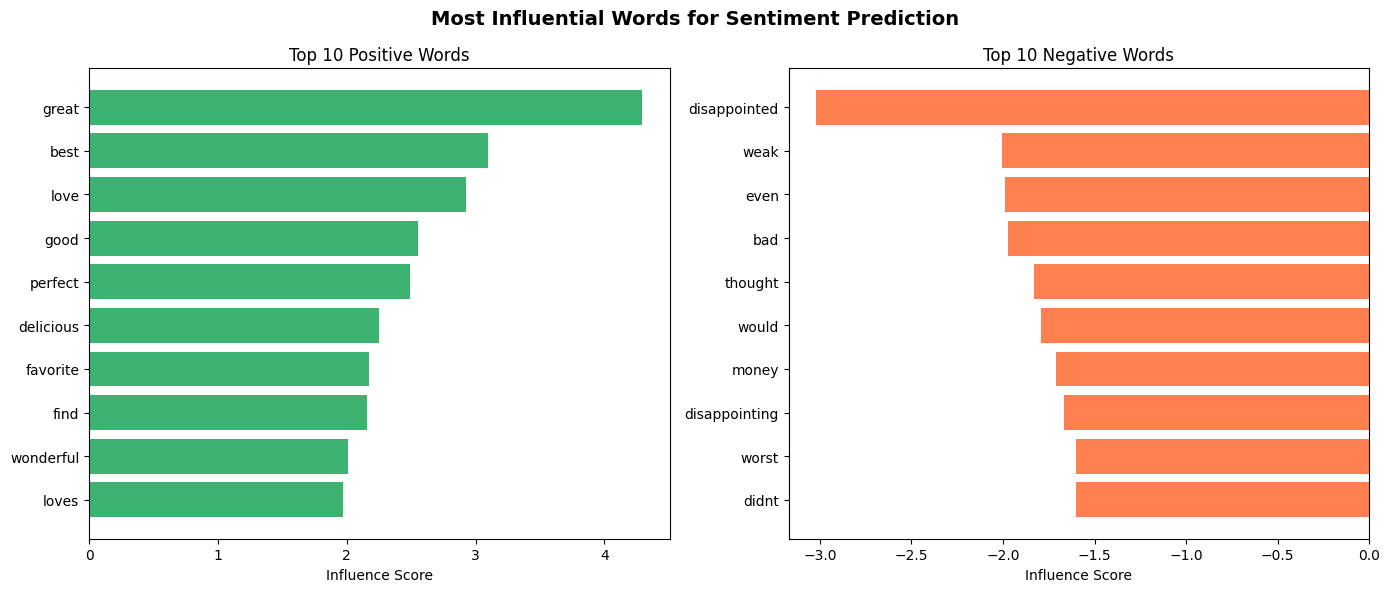

In [15]:
import matplotlib.pyplot as plt
import numpy as np

# Data
pos_words = [word for _, word in top_positive]
pos_scores = [coef for coef, _ in top_positive]

neg_words = [word for _, word in top_negative]
neg_scores = [coef for coef, _ in top_negative]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# Positive words chart
ax1.barh(pos_words, pos_scores, color='mediumseagreen')
ax1.set_title('Top 10 Positive Words')
ax1.set_xlabel('Influence Score')
ax1.invert_yaxis()

# Negative words chart
ax2.barh(neg_words, neg_scores, color='coral')
ax2.set_title('Top 10 Negative Words')
ax2.set_xlabel('Influence Score')
ax2.invert_yaxis()

plt.suptitle('Most Influential Words for Sentiment Prediction',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('influential_words.png')
plt.show()